In [1]:
# Instalações necessárias
!pip install transformers torch scikit-learn pandas spacy nltk matplotlib seaborn
!python -m spacy download pt_core_news_lg

import nltk
# Baixa o dicionário de stopwords (palavras vazias) do NLTK
nltk.download('stopwords')
nltk.download('punkt')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 3.2 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
import pandas as pd
import unicodedata

caminho_arquivo = '/kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv'
df = pd.read_csv(caminho_arquivo, encoding='latin-1', sep='\t')

# 1. Tratamento básico de strings
df['titulo'] = df['Título_Público'].fillna('').astype(str).str.strip()
df['descricao'] = df['Descricao_pública'].fillna('').astype(str).str.strip()

# 2. Reforço de título (dá mais peso ao tema)
df['texto_completo'] = df['titulo'] + ". " + df['titulo'] + ". " + df['descricao']

# 3. Remoção de duplicatas exatas
df = df.drop_duplicates(subset=['texto_completo']).copy()

# 4. Filtro de Ruídos (Projetos confidenciais, cancelados ou vazios)
def identificar_ruido(texto):
    texto_norm = unicodedata.normalize('NFKD', str(texto).lower()).encode('ASCII', 'ignore').decode('utf-8')
    qtd_palavras = len(texto_norm.split())

    curto_demais = qtd_palavras <= 4
    nao_divulgado = "confidencial" in texto_norm or "nao divulgado" in texto_norm
    cancelado = "cancelado" in texto_norm or "pendente definicao" in texto_norm

    return curto_demais or nao_divulgado or cancelado

df['is_ruido'] = df['texto_completo'].apply(identificar_ruido)
df_limpo = df[~df['is_ruido']].copy()

print(f"Total de registros após limpeza de ruídos: {len(df_limpo)}")

df_amostra = df_limpo.copy()

Total de registros após limpeza de ruídos: 2703


In [3]:
from nltk.corpus import stopwords
import re

# Carrega as stopwords em português
stop_words_pt = set(stopwords.words('portuguese'))

# Adiciona algumas stopwords customizadas que costumam poluir textos de projetos
stop_words_pt.update(['desenvolvimento', 'projeto', 'objetivo', 'estudo', 'uso', 'empresa', 'novo', 'nova'])

def limpar_texto_para_grafico(texto):
    # Converte para minúsculo
    texto = str(texto).lower()
    # Remove pontuação e números (deixa só letras)
    texto = re.sub(r'[^a-záéíóúâêôãõç\s]', ' ', texto)

    # Remove as stopwords
    palavras = texto.split()
    palavras_limpas = [p for p in palavras if p not in stop_words_pt and len(p) > 2]

    return " ".join(palavras_limpas)

# Cria uma coluna nova só para a análise exploratória
print("Limpando textos e removendo stopwords...")
df_amostra['texto_limpo'] = df_amostra['texto_completo'].apply(limpar_texto_para_grafico)
print("Textos limpos com sucesso!")

Limpando textos e removendo stopwords...
Textos limpos com sucesso!


In [4]:
import spacy

nlp_base = spacy.load("pt_core_news_lg")
dados_treino = []

for texto in df_amostra['texto_completo']:
    doc = nlp_base(texto)
    entidades = []

    for ent in doc.ents:
        label = ent.label_

        # Correção heurística para o erro de classificação do modelo base
        if ent.text.strip().lower() == 'brasil' and label != 'LOC':
            label = 'LOC'

        entidades.append((ent.start_char, ent.end_char, label))

    if entidades:
        dados_treino.append((texto, {"entities": entidades}))

print(f"Total de textos anotados para treino do novo NER: {len(dados_treino)}")

Total de textos anotados para treino do novo NER: 2134


In [5]:
import random
from spacy.training.example import Example

nlp_novo = spacy.blank("pt")
ner = nlp_novo.add_pipe("ner")

for _, anotacoes in dados_treino:
    for ent in anotacoes.get("entities"):
        ner.add_label(ent[2])

optimizer = nlp_novo.begin_training()

epocas = 10

print("Iniciando treinamento do modelo NER customizado...")
for itn in range(epocas):
    random.shuffle(dados_treino)
    losses = {}

    for texto, anotacoes in dados_treino:
        doc = nlp_novo.make_doc(texto)
        example = Example.from_dict(doc, anotacoes)
        nlp_novo.update([example], sgd=optimizer, drop=0.3, losses=losses)

    print(f"Época {itn+1}/{epocas} concluída - Loss: {losses['ner']:.4f}")

Iniciando treinamento do modelo NER customizado...
Época 1/10 concluída - Loss: 12801.5273
Época 2/10 concluída - Loss: 10858.7051
Época 3/10 concluída - Loss: 9776.3301
Época 4/10 concluída - Loss: 9279.4453
Época 5/10 concluída - Loss: 8764.0996
Época 6/10 concluída - Loss: 8205.0898
Época 7/10 concluída - Loss: 7878.5044
Época 8/10 concluída - Loss: 7426.0098
Época 9/10 concluída - Loss: 7138.4082
Época 10/10 concluída - Loss: 6901.6094


In [6]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de processamento: {device}")

nome_modelo = 'neuralmind/bert-base-portuguese-cased'
tokenizer = AutoTokenizer.from_pretrained(nome_modelo)
modelo_bert = AutoModel.from_pretrained(nome_modelo).to(device)

def extrair_embeddings(texto):
    inputs = tokenizer(texto, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = modelo_bert(**inputs)

    embeddings = outputs.last_hidden_state.mean(dim=1).squeeze()
    return embeddings.cpu().numpy()

print("Gerando representações vetoriais (Embeddings)...")
df_amostra['embeddings'] = df_amostra['texto_completo'].apply(extrair_embeddings)
print("Embeddings gerados!")

Dispositivo de processamento: cuda


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Gerando representações vetoriais (Embeddings)...
Embeddings gerados!


In [7]:
from sklearn.cluster import KMeans

matriz_embeddings = np.vstack(df_amostra['embeddings'].values)

num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')

df_amostra['cluster'] = kmeans.fit_predict(matriz_embeddings)

print("Distribuição de projetos por Cluster:")
tabela_clusters = df_amostra['cluster'].value_counts().reset_index()
tabela_clusters.columns = ['ID do Cluster', 'Quantidade de Projetos']
display(tabela_clusters)

Distribuição de projetos por Cluster:


,ID do Cluster,Quantidade de Projetos
0,3,884
1,0,677
2,2,553
3,4,397
4,1,192


Criando nomes automáticos para os clusters e gerando o t-SNE...


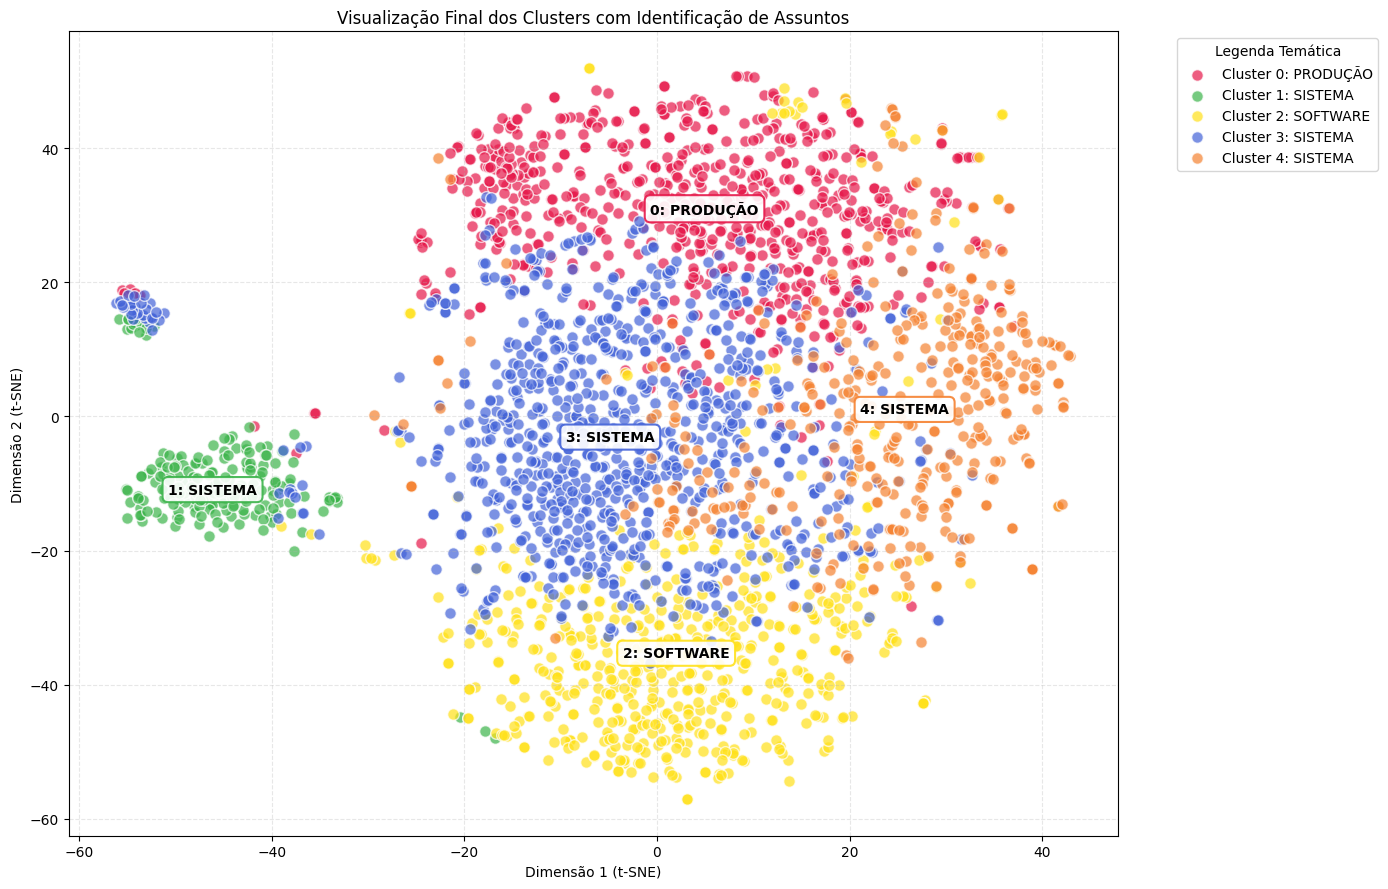

In [8]:
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("Criando nomes automáticos para os clusters e gerando o t-SNE...")

# 1. DESCOBRINDO O NOME DE CADA CLUSTER AUTOMATICAMENTE
nomes_clusters = {}
for cluster_id in sorted(df_amostra['cluster'].unique()):
    dados_do_cluster = df_amostra[df_amostra['cluster'] == cluster_id]

    # Pega apenas a palavra mais forte/exclusiva do grupo
    tfidf = TfidfVectorizer(max_features=1)
    try:
        tfidf.fit_transform(dados_do_cluster['texto_limpo'])
        palavra_chave = tfidf.get_feature_names_out()[0].upper()
        nomes_clusters[cluster_id] = palavra_chave
    except ValueError:
        nomes_clusters[cluster_id] = "GERAL"

# 2. T-SNE OTIMIZADO PARA SEPARAÇÃO DE "ILHAS"
# O init='pca' é o grande truque para espalhar bem os clusters
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
pontos_2d = tsne.fit_transform(matriz_embeddings)

df_amostra['tsne_1'] = pontos_2d[:, 0]
df_amostra['tsne_2'] = pontos_2d[:, 1]

# 3. PLOTANDO O GRÁFICO FINAL (Com as caixinhas de texto)
plt.figure(figsize=(14, 9)) # Tamanho grande igual ao do seu amigo
clusters_ordenados = sorted(df_amostra["cluster"].unique())

# Paleta de cores bem distintas
cores = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe']

for i, cluster_id in enumerate(clusters_ordenados):
    df_cluster = df_amostra[df_amostra["cluster"] == cluster_id]
    cor_atual = cores[i % len(cores)]
    nome_assunto = nomes_clusters[cluster_id]

    plt.scatter(
        df_cluster["tsne_1"], df_cluster["tsne_2"],
        label=f"Cluster {cluster_id}: {nome_assunto}",
        alpha=0.7, s=70, edgecolors='w', color=cor_atual
    )

    x_mediano = df_cluster["tsne_1"].median()
    y_mediano = df_cluster["tsne_2"].median()

    plt.text(
        x_mediano, y_mediano,
        f"{cluster_id}: {nome_assunto}",
        fontsize=10, fontweight='bold',
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=cor_atual, alpha=0.9, lw=1.5)
    )

# Configurações visuais finais
plt.xlabel("Dimensão 1 (t-SNE)")
plt.ylabel("Dimensão 2 (t-SNE)")
plt.title("Visualização Final dos Clusters com Identificação de Assuntos")
plt.legend(title="Legenda Temática", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()

In [9]:
print("--- TESTE DE EXTRAÇÃO DE ENTIDADES COM O MODELO TREINADO ---\n")

amostras_teste = df_amostra['texto_completo'].head(5).values

for texto in amostras_teste:
    doc = nlp_novo(texto)

    entidades_encontradas = [(ent.text, ent.label_) for ent in doc.ents]

    texto_exibicao = texto[:400] + "..." if len(texto) > 400 else texto

    print(f"TEXTO: {texto_exibicao}")
    print(f"ENTIDADES: {entidades_encontradas}")
    print("-" * 100)

--- TESTE DE EXTRAÇÃO DE ENTIDADES COM O MODELO TREINADO ---

TEXTO: Açúcar de frutas e aplicação em bolos como substituto da sacarose. Açúcar de frutas e aplicação em bolos como substituto da sacarose. O uso de inovações tecnológicas auxilia as indústrias a desenvolverem modelos sustentáveis de produção, produtos e serviços de forma sustentável a partir de recursos de base biológica com papel importante no desenvolvimento econômico do Brasil, dessa maneira, contri...
ENTIDADES: [('Brasil', 'LOC'), ('Objetivos de Desenvolvimento Sustentável', 'ORG'), ('ODS', 'ORG'), ('Organização das Nações Unidas', 'ORG'), ('ONU', 'ORG'), ('Objetivo 12', 'MISC')]
----------------------------------------------------------------------------------------------------
TEXTO: Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal. Desenvolver uma linha de farofas com castanhas brasileiras e adição de proteína animal. O uso de inovações tecnológicas auxilia as indústrias a dese